#### Single-mode coupled mode theory — Laís thesis Eq. (4.5)

Solves:
    $$ \frac{da_0}{d\tau} = -(1 + iΔ₀) a₀  -  i|a₀|² a₀  +  s $$

Variables (all dimensionless, normalized to κ/2):
- $\tau$      = (κ/2) t             — normalized time
- a₀     = √(2g₀/κ) A₀        — normalized intracavity amplitude
- Δ₀     = (2/κ)(ωp - ω₀)     — normalized detuning (positive = blue)
- s      = √(8η g₀/κ³) S_in   — normalized drive amplitude
- |s|²   = 2η P_in / P_th     — so s=1 means P_in = P_th/2η ≈ P_th

We scan Δ₀ slowly across the resonance (from blue to red, i.e. Δ → -Δ)
to simulate the experimental laser-frequency sweep.

Physical interpretation of each term:
- -(1)·a₀        : cavity decay (loss rate = κ/2, normalized to 1)
- -iΔ₀·a₀        : detuning — field rotates at residual frequency Δ₀
- -i|a₀|²·a₀     : Kerr SPM — intensity shifts resonance (g absorbed into a)
- +s              : coherent pump drive


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp

sns.set_theme()

##### Equation of motion


In [2]:
def da_dt(tau, state, Delta, s):
    """
    Right-hand side of the single-mode CMT equation.

    state : [Re(a), Im(a)]  — split into real parts for the ODE solver
    Delta : normalized detuning at this instant
    s     : real drive amplitude (s ≥ 0)
    """
    a = state[0] + 1j * state[1]          # reconstruct complex amplitude

    dadt = -(1 + 1j * Delta) * a  -  1j * abs(a)**2 * a  +  s

    return [dadt.real, dadt.imag]


##### Detuning sweep


In [3]:
def sweep(s, Delta_range, n_points=2000, tau_settle=30):
    """
    Slowly scan Δ₀ across the resonance, letting the field settle at each step.

    At each detuning step, we:
      1. Integrate the ODE for tau_settle time units (field settles to steady state)
      2. Record |a|² and |s - a|² (transmission) at the end

    Returns:
        Deltas   : array of detuning values
        n_intra  : intracavity photon number |a|²
        T        : transmission |s - a|²
    """
    Deltas   = np.linspace(Delta_range[0], Delta_range[1], n_points)
    n_intra  = np.zeros(n_points)
    T        = np.zeros(n_points)

    # Start with a = 0 (empty cavity)
    state = [0.0, 0.0]

    for k, Delta in enumerate(Deltas):
        sol = solve_ivp(
            fun     = lambda tau, y: da_dt(tau, y, Delta, s),
            t_span  = (0, tau_settle),
            y0      = state,
            method  = 'RK45',
            rtol    = 1e-8,
            atol    = 1e-10,
            dense_output = False,
        )
        state = sol.y[:, -1]              # use final state as IC for next step

        a = state[0] + 1j * state[1]
        n_intra[k] = abs(a)**2
        T[k]       = abs(s - a)**2        # output field = input - coupled-out field

    return Deltas, n_intra, T


In [4]:
# Drive amplitudes: s=1 → P ≈ P_th;  s=√3 → P ≈ 3P_th (threshold for bistability)
# Bistability requires s² > 4/(3√3) ≈ 0.77, i.e. s > 0.88
drive_values = [0.5, 1.0, 1.5, 2.0]   # normalized drive amplitudes


In [5]:
# Scan blue-to-red (positive to negative detuning)
Delta_range_fwd = ( 5.0, -5.0)   # forward scan (blue→red)
Delta_range_bwd = (-5.0,  5.0)   # backward scan (red→blue), shows hysteresis


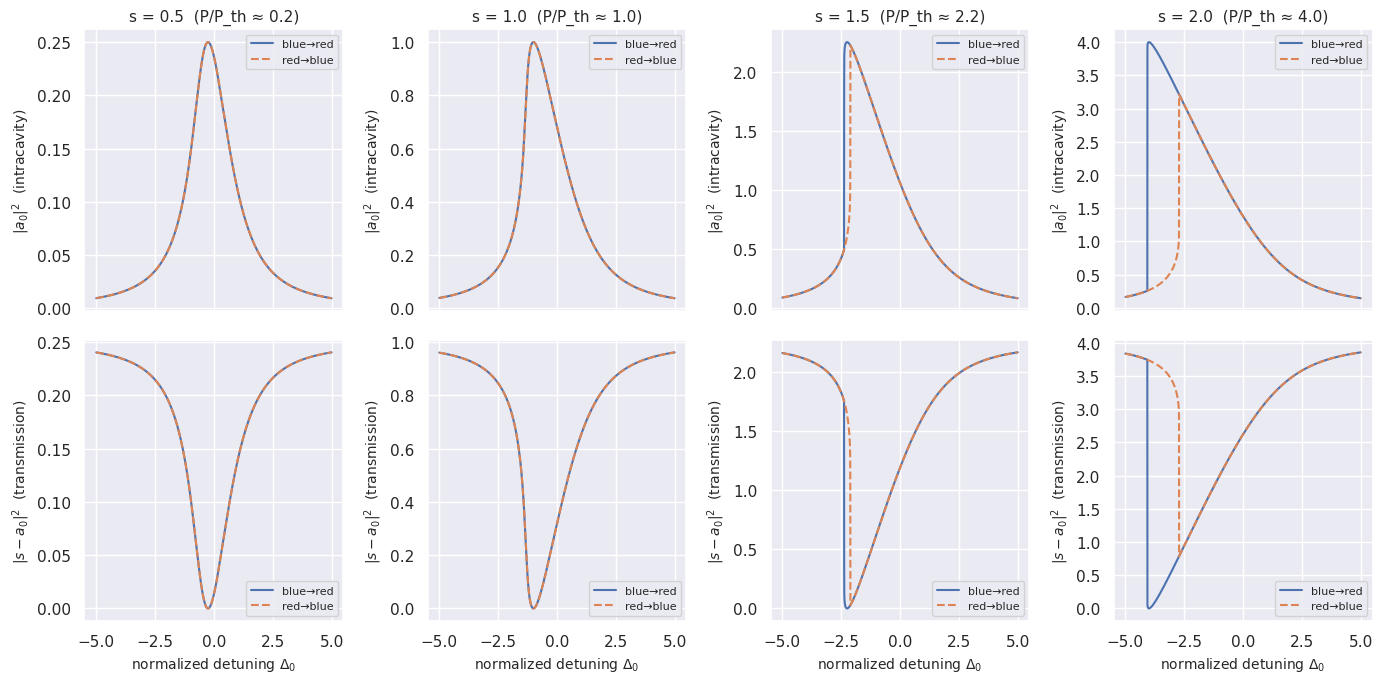

In [8]:
fig, axes = plt.subplots(2, len(drive_values), figsize=(14, 7), sharex=True)
# fig.suptitle(
#     "Single-mode CMT  —  thesis Eq. (4.5)\n"
#     r"$\dot{a}_0 = -(1+i\Delta_0)a_0 - i|a_0|^2 a_0 + s$",
#     fontsize=13
# )


for ind, s in enumerate(drive_values):
    D_fwd, n_fwd, T_fwd = sweep(s, Delta_range_fwd)
    D_bwd, n_bwd, T_bwd = sweep(s, Delta_range_bwd)

    ax_top = axes[0, ind]
    ax_bot = axes[1, ind]

    # Intracavity power
    ax_top.plot(D_fwd, n_fwd, color="C00", lw=1.5, label='blue→red')
    ax_top.plot(D_bwd, n_bwd, color="C01", lw=1.5, ls='--', label='red→blue')
    ax_top.set_title(f's = {s}  (P/P_th ≈ {s**2:.1f})', fontsize=11)
    ax_top.set_ylabel(r'$|a_0|^2$  (intracavity)', fontsize=10)
    ax_top.legend(loc=1, fontsize=8)


    ax_bot.plot(D_fwd, T_fwd, color="C00", lw=1.5, label='blue→red')
    ax_bot.plot(D_bwd, T_bwd, color="C01", lw=1.5, ls='--', label='red→blue')
    ax_bot.set_ylabel(r'$|s - a_0|^2$  (transmission)', fontsize=10)
    ax_bot.set_xlabel(r'normalized detuning $\Delta_0$', fontsize=10)
    ax_bot.legend(loc=4, fontsize=8)


fig.tight_layout()
fig.savefig("../figures/01_SM_Bistability.pdf")


#### Steady-state analytic check
At steady state da/dt = 0, so:

$\vert a\vert ^2 * [(1)^2 + (\Delta - \vert a\vert ^2)^2]  = s^2$

We solve this numerically and overlay on the simulation to verify.


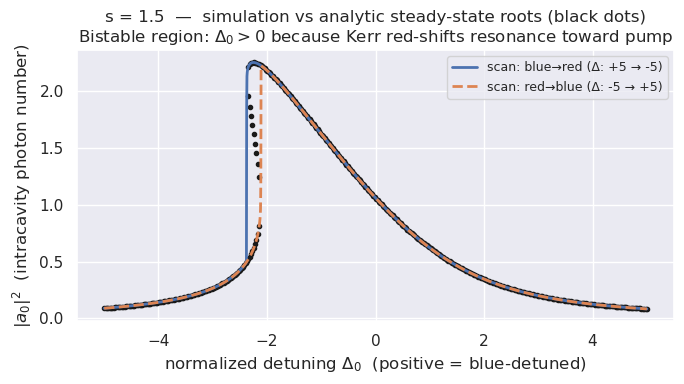

In [6]:
s_check = 1.5
Deltas_check = np.linspace(-5, 5, 400)

n_analytic   = []

for ind, D in enumerate(Deltas_check):
    # Roots of: n³ + 2Δn² + (1+Δ²)n - s² = 0,  where n = |a|²
    coeffs = [1, +2*D, (1 + D**2), -s_check**2]
    roots  = np.roots(coeffs)
    real_positive = [r.real for r in roots if abs(r.imag) < 1e-9 and r.real >= 0]
    n_analytic.append(real_positive)

fig2, ax2 = plt.subplots(figsize=(7, 4))

# # Analytic roots — plotted left-to-right (Δ increasing)
for k, D in enumerate(Deltas_check):
    for n_val in n_analytic[k]:
        ax2.plot(D, n_val, 'k.')



D_fwd, n_fwd, _ = sweep(s_check, (+5, -5))   # blue→red: starts high-Δ
ax2.plot(D_fwd, n_fwd, lw=2, label='scan: blue→red (Δ: +5 → -5)')


D_bwd, n_bwd, _ = sweep(s_check, (-5, +5))   # red→blue: starts low-Δ
ax2.plot(D_bwd, n_bwd, lw=2, ls='--', label='scan: red→blue (Δ: -5 → +5)')



ax2.set_xlabel(r'normalized detuning $\Delta_0$  (positive = blue-detuned)')
ax2.set_ylabel(r'$|a_0|^2$  (intracavity photon number)')
ax2.set_title(
    f's = {s_check}  —  simulation vs analytic steady-state roots (black dots)\n'
    r'Bistable region: $\Delta_0 > 0$ because Kerr red-shifts resonance toward pump'
)
ax2.legend(loc=1, fontsize=9);

fig2.tight_layout()
fig2.savefig("../figures/01_SM_Analytic solution comparison.pdf")
